In [1]:
import matplotlib.dates as mdates

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset Information:
# The online_retail.csv contains 387961 rows and 8 columns.

df = pd.read_csv('OnlineRetail.csv', encoding='latin-1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(401604, 8)

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df[df['Quantity']>=0].shape

(392732, 8)

In [9]:
df = df[df['Quantity']>=0]

In [10]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [12]:
df['InvoiceNo'] = pd.to_numeric(df['InvoiceNo'],errors = 'coerce')

C:\Users\MrAmi\AppData\Local\Temp\ipykernel_3464\3261189733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceNo'] = pd.to_numeric(df['InvoiceNo'],errors = 'coerce')


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

C:\Users\MrAmi\AppData\Local\Temp\ipykernel_3464\3633860036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  int64         
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 27.0+ MB


In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(392732, 8)

In [18]:
df.describe(include='O')

,StockCode,Description,Country
count,392732,392732,392732
unique,3665,3877,37
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,2023,2016,349227


In [19]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2016
REGENCY CAKESTAND 3 TIER               1714
JUMBO BAG RED RETROSPOT                1615
ASSORTED COLOUR BIRD ORNAMENT          1395
PARTY BUNTING                          1390
                                       ... 
ROCOCO WALL MIROR                         1
POTTING SHED SOW 'N' GROW SET             1
PINK CRYSTAL GUITAR PHONE CHARM           1
GLASS AND PAINTED BEADS BRACELET OL       1
PAPER CRAFT , LITTLE BIRDIE               1
Name: count, Length: 3877, dtype: int64

In [20]:
df['Country'].value_counts()

Country
United Kingdom          349227
Germany                   9027
France                    8327
EIRE                      7228
Spain                     2480
Netherlands               2363
Belgium                   2031
Switzerland               1842
Portugal                  1453
Australia                 1184
Norway                    1072
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         58
Lebanon                     45


In [21]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392732.000000,392732.000000,392732,392732.000000,392732.000000
mean,560591.072436,13.153718,2011-07-10 19:15:24.576301568,3.125596,15287.734822
min,536365.000000,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,13087.116747,181.588420,NaN,22.240725,1713.567773


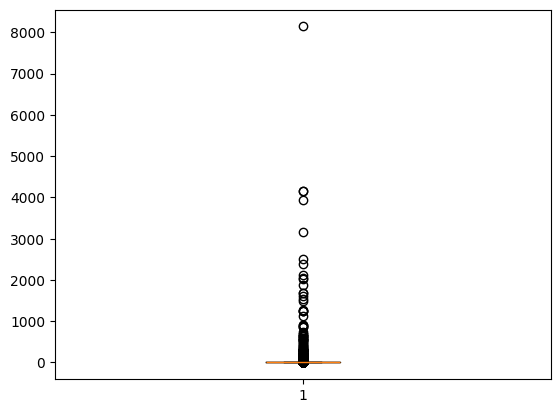

In [22]:
plt.boxplot(df['UnitPrice'])
plt.show()

In [23]:
df['total_price'] = (df['Quantity'] * df['UnitPrice']).round(2)

C:\Users\MrAmi\AppData\Local\Temp\ipykernel_3464\3678176857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_price'] = (df['Quantity'] * df['UnitPrice']).round(2)


In [24]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [25]:
df['Quantity'].value_counts()

Quantity
1        69605
12       59828
2        57425
6        37480
4        32093
         ...  
59           1
388          1
1404         1
698          1
80995        1
Name: count, Length: 302, dtype: int64

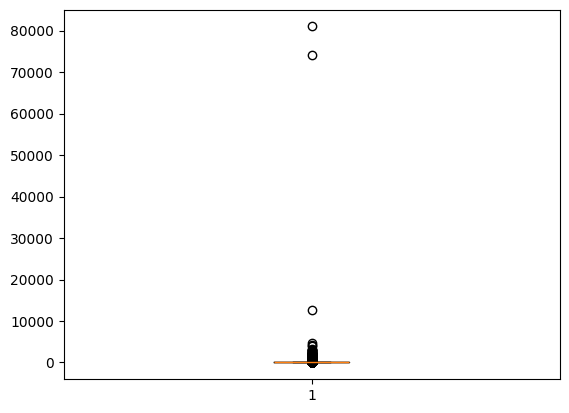

In [26]:
plt.boxplot(df['Quantity'])
plt.show()

In [27]:
df.info(
    
)

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  int64         
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
 8   total_price  392732 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 30.0+ MB


In [28]:
df[df['Quantity'] > 10000][['InvoiceNo', 'Quantity', 'UnitPrice', 'Country', 'Description']]


,InvoiceNo,Quantity,UnitPrice,Country,Description
61619,541431,74215,1.04,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR
502122,578841,12540,0.00,United Kingdom,ASSTD DESIGN 3D PAPER STICKERS
540421,581483,80995,2.08,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE"


In [29]:
df[df['UnitPrice'] > 1000][['InvoiceNo', 'Quantity', 'UnitPrice', 'Country', 'Description']]

,InvoiceNo,Quantity,UnitPrice,Country,Description
117054,546328,1,1687.17,EIRE,Manual
117055,546329,1,1687.17,EIRE,Manual
144826,548813,1,2382.92,Singapore,Manual
144828,548813,1,1252.95,Singapore,Manual
144829,548820,1,2053.07,Singapore,Manual
145831,548913,1,1136.30,France,Manual
150615,549468,1,1867.86,United Kingdom,Manual
173382,551697,1,8142.75,United Kingdom,POSTAGE
200745,554155,1,1241.98,Portugal,Manual
201553,554301,1,1241.98,Portugal,Manual


In [30]:
df.shape

(392732, 9)

In [31]:
392732- 387961 

4771

In [32]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2016
REGENCY CAKESTAND 3 TIER               1714
JUMBO BAG RED RETROSPOT                1615
ASSORTED COLOUR BIRD ORNAMENT          1395
PARTY BUNTING                          1390
                                       ... 
ROCOCO WALL MIROR                         1
POTTING SHED SOW 'N' GROW SET             1
PINK CRYSTAL GUITAR PHONE CHARM           1
GLASS AND PAINTED BEADS BRACELET OL       1
PAPER CRAFT , LITTLE BIRDIE               1
Name: count, Length: 3877, dtype: int64

In [33]:
df[df['Description'].isin(['Manual', 'POSTAGE', 'DOTCOM POSTAGE'])].shape

(1400, 9)

In [34]:
df = df[~df['Description'].isin(['Manual', 'POSTAGE', 'DOTCOM POSTAGE'])]

df.shape  

(391332, 9)

In [35]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [36]:
# sns.lineplot(df, x = 'InvoiceDate', y = 'total_price')

In [37]:
revenue_timeline = df.loc[:,['InvoiceDate', 'total_price']]
revenue_timeline.set_index('InvoiceDate', inplace=True)

In [38]:
revenue_timeline

,total_price
InvoiceDate,
2010-12-01 08:26:00,15.30
2010-12-01 08:26:00,20.34
2010-12-01 08:26:00,22.00
2010-12-01 08:26:00,20.34
2010-12-01 08:26:00,20.34
...,...
2011-12-09 12:50:00,10.20
2011-12-09 12:50:00,12.60
2011-12-09 12:50:00,16.60


In [39]:
weekly_sales = revenue_timeline['total_price'].resample('W').sum()

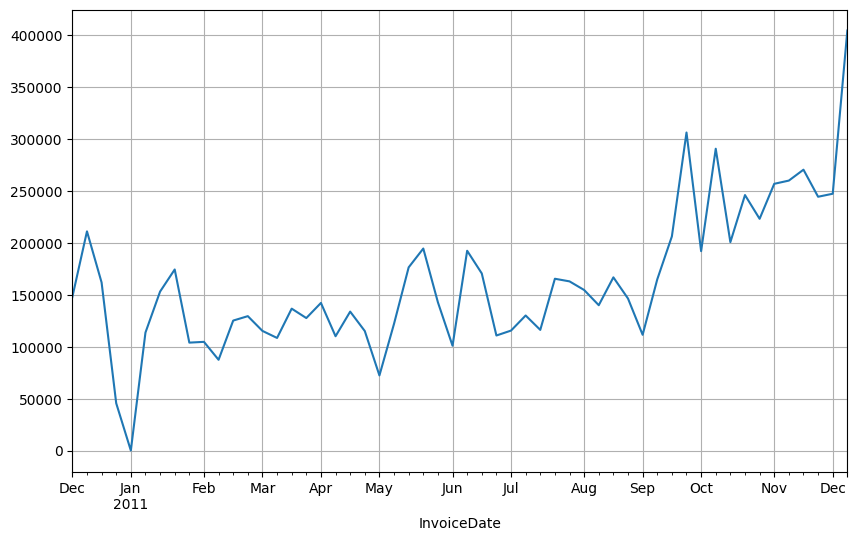

In [40]:
weekly_sales.plot(figsize=(10,6))
plt.grid()
plt.show()

In [41]:
weekly_sales = weekly_sales.reset_index()

In [42]:
weekly_sales

,InvoiceDate,total_price
0,2010-12-05,147701.11
1,2010-12-12,210878.74
2,2010-12-19,161698.80
3,2010-12-26,45485.91
4,2011-01-02,0.00
5,2011-01-09,113523.05
6,2011-01-16,152926.90
7,2011-01-23,174199.48
8,2011-01-30,103820.00
9,2011-02-06,104562.86


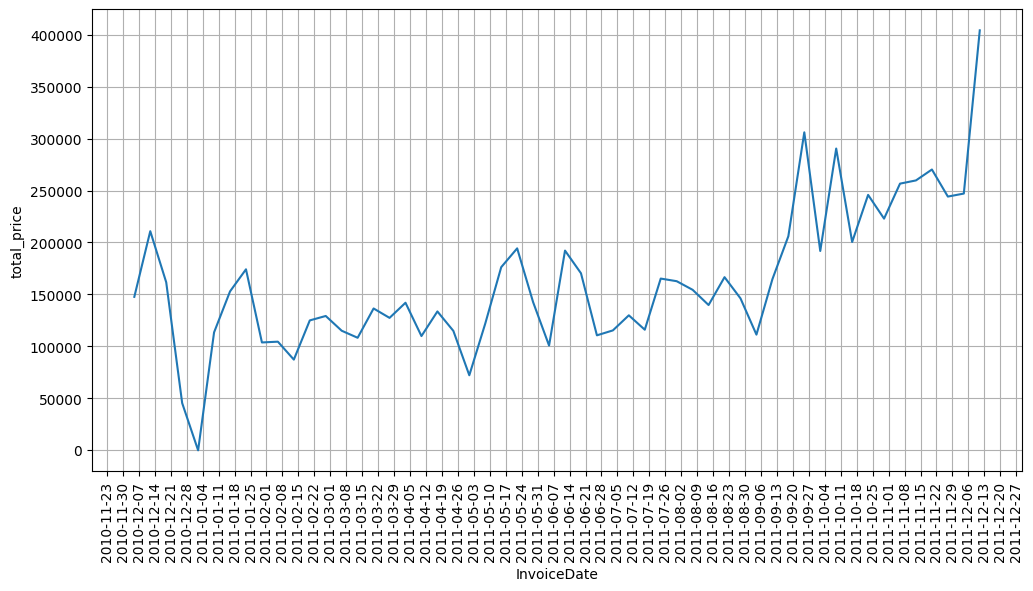

In [43]:
plt.figure(figsize=(12,6))
sns.lineplot(weekly_sales, x = 'InvoiceDate', y = 'total_price')
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation = 90)
plt.grid()
plt.show()

In [44]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [45]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title = 'Online')
# profile.to_file('online.html')

In [46]:
# 1. How much does each customer spend?
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [47]:
df['CustomerID'] = df['CustomerID'].astype(int)

C:\Users\MrAmi\AppData\Local\Temp\ipykernel_3464\4010221730.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerID'] = df['CustomerID'].astype(int)


In [48]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [49]:
df.groupby('CustomerID')['total_price'].sum().sort_values(ascending=False)

CustomerID
14646    279138.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    140336.83
           ...    
17956        12.75
14792         6.20
16454         5.90
16738         3.75
13256         0.00
Name: total_price, Length: 4336, dtype: float64

In [50]:
# 2. How many orders per customer?

df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

CustomerID
12748    206
14911    199
17841    124
13089     97
15311     91
        ... 
18276      1
18274      1
18269      1
18268      1
12361      1
Name: InvoiceNo, Length: 4336, dtype: int64

In [51]:
# 3. Average order value per customer

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [52]:
df.groupby('CustomerID')['total_price'].mean().sort_values(ascending=False)

CustomerID
12346    77183.600000
16446    56157.500000
15098    13305.500000
15749     4453.430000
15195     3861.000000
             ...     
13271        2.430920
13684        2.245862
17816        2.150588
15503        2.136970
13256        0.000000
Name: total_price, Length: 4336, dtype: float64

In [53]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [54]:
customer_report = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('total_price', 'sum')
).round(2)

In [58]:
customer_report

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [59]:
customer_report['R_Label'] = pd.cut(customer_report['Recency'], bins = 3, labels = ['H', 'M', 'L'])
customer_report['F_Label'] = pd.cut(customer_report['Frequency'], bins = 3, labels = ['H', 'M', 'L'])
customer_report['M_Label'] = pd.cut(customer_report['Monetary'], bins = 3, labels = ['H', 'M', 'L'])

In [60]:
customer_report

,Recency,Frequency,Monetary,R_Label,F_Label,M_Label
CustomerID,,,,,,
12346,326,1,77183.60,L,H,H
12347,2,7,4310.00,H,H,H
12348,75,4,1437.24,H,H,H
12349,19,1,1457.55,H,H,H
12350,310,1,294.40,L,H,H
...,...,...,...,...,...,...
18280,278,1,180.60,L,H,H
18281,181,1,80.82,M,H,H
18282,8,2,178.05,H,H,H


<Axes: xlabel='R_Label', ylabel='count'>

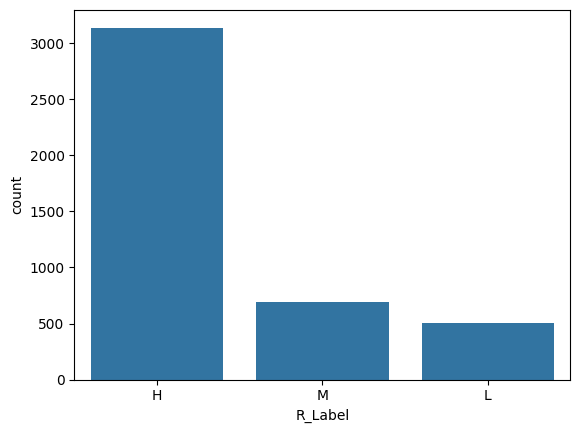

In [65]:
sns.countplot(customer_report, x = 'R_Label')

In [68]:
customer_report['Segment (RFM)'] = customer_report['R_Label'].astype(str) + customer_report['F_Label'].astype(str) + customer_report['M_Label'].astype(str)

In [69]:
customer_report

,Recency,Frequency,Monetary,R_Label,F_Label,M_Label,Segment,Segment (RFM)
CustomerID,,,,,,,,
12346,326,1,77183.60,L,H,H,LHH,LHH
12347,2,7,4310.00,H,H,H,HHH,HHH
12348,75,4,1437.24,H,H,H,HHH,HHH
12349,19,1,1457.55,H,H,H,HHH,HHH
12350,310,1,294.40,L,H,H,LHH,LHH
...,...,...,...,...,...,...,...,...
18280,278,1,180.60,L,H,H,LHH,LHH
18281,181,1,80.82,M,H,H,MHH,MHH
18282,8,2,178.05,H,H,H,HHH,HHH


In [70]:
customer_report.drop(columns=('Segment'), inplace=True)

In [71]:
customer_report

,Recency,Frequency,Monetary,R_Label,F_Label,M_Label,Segment (RFM)
CustomerID,,,,,,,
12346,326,1,77183.60,L,H,H,LHH
12347,2,7,4310.00,H,H,H,HHH
12348,75,4,1437.24,H,H,H,HHH
12349,19,1,1457.55,H,H,H,HHH
12350,310,1,294.40,L,H,H,LHH
...,...,...,...,...,...,...,...
18280,278,1,180.60,L,H,H,LHH
18281,181,1,80.82,M,H,H,MHH
18282,8,2,178.05,H,H,H,HHH


In [72]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60
